# Real language-model I/O laboratory

Runs on CPU; the first run downloads DistilGPT2 weights (hundreds of MB) from Hugging Face. Allow at least 2 GB free memory and network access. This is a small English pretrained model, not a chat assistant. Attention plots come from actual forward passes. Target transformers 4.57.1; for another environment run `%pip install transformers==4.57.1` and restart the kernel.

Execution status: executed on CPU during authoring. Outputs below are real; CUDA/TPU paths were not tested. Rerun to obtain results for your environment.

In [1]:
import sys, subprocess, importlib.util
needed = [p for p in ['torch','transformers','numpy','matplotlib','PIL'] if importlib.util.find_spec(p) is None]
if needed:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch>=2.6,<3', 'transformers==4.57.1', 'numpy', 'matplotlib', 'pillow'])
import torch, numpy as np, matplotlib.pyplot as plt, transformers
print({'python':sys.version.split()[0], 'torch':torch.__version__, 'transformers':transformers.__version__, 'cuda':torch.cuda.is_available()})
torch.manual_seed(7); np.random.seed(7)
torch.set_num_threads(min(4, torch.get_num_threads()))


{'python': '3.12.14', 'torch': '2.14.0+cpu', 'transformers': '4.57.1', 'cuda': False}


## 1 · Configuration and reproducible inputs
Edit the prompt and predict its token count. MODEL_REVISION can be a pinned commit; the resolved revision is printed.

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
MODEL_ID = 'distilbert/distilgpt2'
MODEL_REVISION = 'main'
PROMPT = 'The cat is sleeping on the'
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, revision=MODEL_REVISION, attn_implementation='eager').eval()
inputs = tokenizer(PROMPT, return_tensors='pt', truncation=True, max_length=128)
print('resolved revision:', model.config._commit_hash)
print({k:tuple(v.shape) for k,v in inputs.items()})
ids = inputs['input_ids'][0].tolist()
tokens = tokenizer.convert_ids_to_tokens(ids)
print(list(zip(ids,tokens)))
print('layers / heads / hidden:', model.config.n_layer, model.config.n_head, model.config.n_embd)


resolved revision: 2290a62682d06624634c1f46a6ad5be0f47f38aa
{'input_ids': (1, 6), 'attention_mask': (1, 6)}
[(464, 'The'), (3797, 'Ġcat'), (318, 'Ġis'), (11029, 'Ġsleeping'), (319, 'Ġon'), (262, 'Ġthe')]
layers / heads / hidden: 6 12 768


## 2 · What a forward pass returns
Distinguish input embeddings, layer states and vocabulary logits.

In [3]:
with torch.no_grad():
    out = model(**inputs, output_hidden_states=True, output_attentions=True, use_cache=True)
print('logits:',tuple(out.logits.shape))
print('hidden states:',[tuple(h.shape) for h in out.hidden_states])
print('attention:',[tuple(a.shape) for a in out.attentions])
assert out.logits.shape[:2] == inputs['input_ids'].shape
assert len(out.hidden_states) == model.config.n_layer+1
p = out.logits[0,-1].softmax(-1)
values, indices = p.topk(8)
for index,value in zip(indices.tolist(), values.tolist()):
    print(repr(tokenizer.decode([index])),round(value,6))


logits: (1, 6, 50257)
hidden states: [(1, 6, 768), (1, 6, 768), (1, 6, 768), (1, 6, 768), (1, 6, 768), (1, 6, 768), (1, 6, 768)]
attention: [(1, 12, 6, 6), (1, 12, 6, 6), (1, 12, 6, 6), (1, 12, 6, 6), (1, 12, 6, 6), (1, 12, 6, 6)]
' floor' 0.149088
' bed' 0.098897
' couch' 0.092167
' ground' 0.087733
' sofa' 0.04772
' roof' 0.019405
' side' 0.017463
' porch' 0.015866


## 3 · Visualize actual attention
Change LAYER / HEAD. Columns are read positions and rows are queries. This is not a causal explanation.

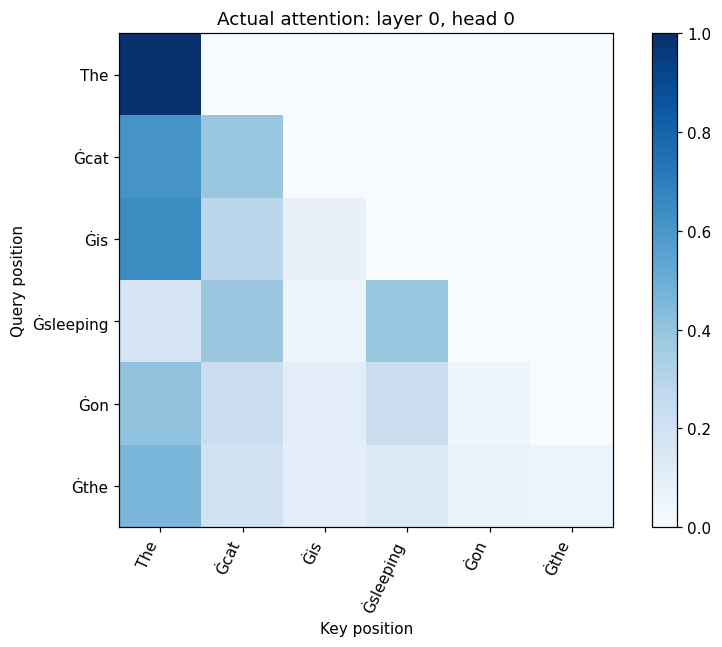

In [4]:
LAYER, HEAD = 0, 0
weights = out.attentions[LAYER][0,HEAD].detach().cpu()
assert torch.allclose(weights.sum(-1),torch.ones(weights.shape[0]),atol=1e-5)
assert weights.triu(1).abs().max().item() < 1e-6
fig,ax=plt.subplots(figsize=(8,6))
im=ax.imshow(weights.numpy(),cmap='Blues',vmin=0)
ax.set_xticks(range(len(tokens)),tokens,rotation=65,ha='right')
ax.set_yticks(range(len(tokens)),tokens)
ax.set(xlabel='Key position',ylabel='Query position',title=f'Actual attention: layer {LAYER}, head {HEAD}')
fig.colorbar(im,ax=ax);plt.tight_layout();plt.show()


## 4 · Check KV-cache equivalence
One unpadded sequence: cache its prefix, then feed only the last token. Do not append the entire prompt again.

In [5]:
assert inputs['input_ids'].shape[1] >= 2
with torch.no_grad():
    prefix = model(input_ids=inputs['input_ids'][:,:-1],use_cache=True)
    last = model(input_ids=inputs['input_ids'][:,-1:],past_key_values=prefix.past_key_values,use_cache=True)
max_error=(last.logits[:,-1]-out.logits[:,-1]).abs().max().item()
print('full vs cached max error:',max_error)
assert torch.allclose(last.logits[:,-1],out.logits[:,-1],atol=1e-4,rtol=1e-4)


full vs cached max error: 0.0001678466796875


## 5 · Temperature and generation
Compare entropy, then greedy and sampled output. A fixed seed does not ensure bitwise equality across devices and versions.

In [6]:
for temperature in [.3,1.,2.]:
    prob=(out.logits[0,-1]/temperature).softmax(-1)
    entropy=-(prob*prob.clamp_min(1e-20).log()).sum()
    print('temperature / entropy:',temperature,entropy.item())
with torch.no_grad():
    greedy=model.generate(**inputs,max_new_tokens=24,do_sample=False,pad_token_id=tokenizer.eos_token_id)
    torch.manual_seed(7)
    sampled=model.generate(**inputs,max_new_tokens=24,do_sample=True,temperature=.8,top_p=.9,pad_token_id=tokenizer.eos_token_id)
print('greedy:',tokenizer.decode(greedy[0],skip_special_tokens=True))
print('sample:',tokenizer.decode(sampled[0],skip_special_tokens=True))


temperature / entropy: 0.3 1.1646475791931152
temperature / entropy: 1.0 4.616281509399414
temperature / entropy: 2.0 9.22627067565918
greedy: The cat is sleeping on the floor.






















sample: The cat is sleeping on the bed, and is trying to sleep.




The cat has been awake for at least two hours.


## Next experiment
Change one parameter, predict the result and rerun. Record the environment, seed, inputs and failures. Do not extrapolate teaching results into production conclusions.